In [96]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.stattools import adfuller
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant
import warnings
warnings.filterwarnings("ignore")

plt.rcParams.update({"font.size": 11, "figure.dpi": 130,
                     "axes.spines.top": False, "axes.spines.right": False})

In [97]:
df = pd.read_csv("../data/merged.csv", parse_dates=["date"])
df = df.dropna(subset=["petrol_inr_delhi", "diesel_inr_delhi",
                        "brent_usd", "crude_inr_per_barrel"])
df = df.sort_values("date").reset_index(drop=True)

print(f"Observations: {len(df)}")
print(f"Date range: {df['date'].min().date()} → {df['date'].max().date()}")
df.tail()

Observations: 67
Date range: 2017-05-01 → 2022-12-01


,date,petrol_inr_delhi,diesel_inr_delhi,brent_usd,inr_per_usd,crude_inr_per_barrel
62,2022-07-01,96.72,89.62,108.92,80.601884,8779.157152
63,2022-08-01,96.72,89.62,98.60,80.934782,7980.169538
64,2022-09-01,96.72,89.62,90.16,81.267681,7327.094133
65,2022-10-01,96.72,89.62,93.13,81.600580,7599.462014
66,2022-12-01,96.72,89.62,80.90,82.266378,6655.349950


In [98]:
# The source only records price-change dates, not every month
# Forward-fill to get a proper monthly panel
full_dates = pd.date_range(df["date"].min(), df["date"].max(), freq="MS")
df = df.set_index("date").reindex(full_dates).reset_index()
df.rename(columns={"index": "date"}, inplace=True)

# Forward fill retail prices (price stays until next revision)
df["petrol_inr_delhi"] = df["petrol_inr_delhi"].ffill()
df["diesel_inr_delhi"] = df["diesel_inr_delhi"].ffill()

# Brent is already monthly — just interpolate the few missing values
df["brent_usd"] = df["brent_usd"].interpolate("linear")

df = df.dropna(subset=["petrol_inr_delhi", "diesel_inr_delhi", "brent_usd"])
df = df.sort_values("date").reset_index(drop=True)

print(f"After forward-fill: {len(df)} monthly rows")
df[["date","petrol_inr_delhi","diesel_inr_delhi","brent_usd"]].tail(10)

After forward-fill: 68 monthly rows


,date,petrol_inr_delhi,diesel_inr_delhi,brent_usd
58,2022-03-01,95.41,86.67,115.590
59,2022-04-01,101.81,93.07,105.780
60,2022-05-01,105.41,96.67,112.370
61,2022-06-01,89.62,96.72,120.080
62,2022-07-01,96.72,89.62,108.920
63,2022-08-01,96.72,89.62,98.600
64,2022-09-01,96.72,89.62,90.160
65,2022-10-01,96.72,89.62,93.130
66,2022-11-01,96.72,89.62,87.015
67,2022-12-01,96.72,89.62,80.900


In [99]:
df[["petrol_inr_delhi", "diesel_inr_delhi", "brent_usd", "crude_inr_per_barrel"]].describe().round(2)

,petrol_inr_delhi,diesel_inr_delhi,brent_usd,crude_inr_per_barrel
count,68.00,68.00,68.00,67.00
mean,81.51,73.39,67.73,4995.95
std,12.09,12.13,19.85,1699.77
min,63.09,53.33,23.34,1728.42
25%,71.61,64.96,56.14,3999.30
50%,77.30,69.30,65.31,4712.73
75%,94.72,86.67,75.56,5584.87
max,109.69,98.42,120.08,9638.70


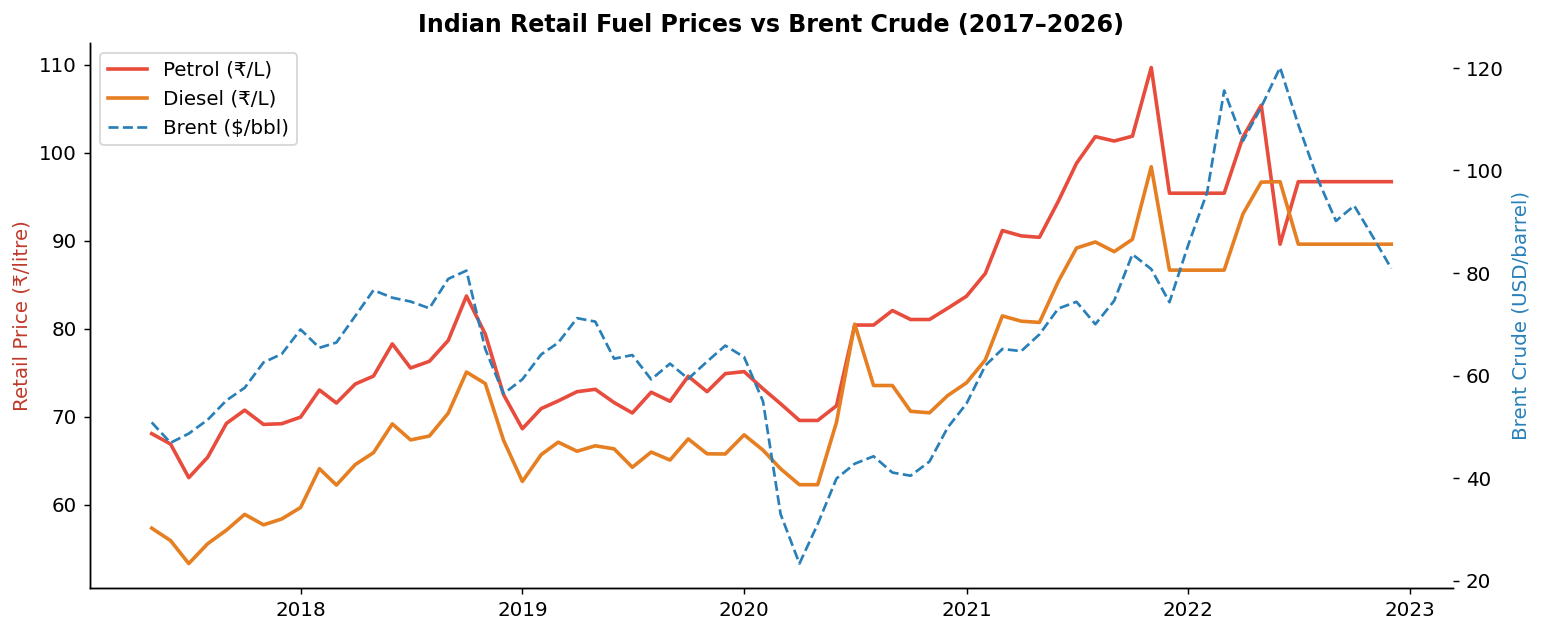

In [100]:
fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

ax1.plot(df["date"], df["petrol_inr_delhi"], color="#e74c3c", lw=2, label="Petrol (₹/L)")
ax1.plot(df["date"], df["diesel_inr_delhi"], color="#e67e22", lw=2, label="Diesel (₹/L)")
ax2.plot(df["date"], df["brent_usd"], color="#2980b9", lw=1.5, ls="--", label="Brent ($/bbl)")

ax1.set_ylabel("Retail Price (₹/litre)", color="#c0392b")
ax2.set_ylabel("Brent Crude (USD/barrel)", color="#2980b9")
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.title("Indian Retail Fuel Prices vs Brent Crude (2017–2026)", fontweight="bold")
plt.tight_layout()
plt.show()

In [ ]:
print("ADF Unit Root Tests")

# Drop NaNs to avoid adfuller errors
df_adf = df[["petrol_inr_delhi", "diesel_inr_delhi", "crude_inr_per_barrel"]].dropna()

series_to_test = {
    "Petrol (levels)":      df_adf["petrol_inr_delhi"],
    "Diesel (levels)":      df_adf["diesel_inr_delhi"],
    "Crude INR (levels)":   df_adf["crude_inr_per_barrel"],
    "Petrol (1st diff)":    df_adf["petrol_inr_delhi"].diff().dropna(),
    "Diesel (1st diff)":    df_adf["diesel_inr_delhi"].diff().dropna(),
    "Crude INR (1st diff)": df_adf["crude_inr_per_barrel"].diff().dropna(),
}

for name, series in series_to_test.items():
    stat, pval, *_ = adfuller(series)
    result = "✓ Stationary" if pval < 0.05 else "✗ Non-stationary"
    print(f"  {name:<25}  ADF={stat:7.3f}  p={pval:.3f}  {result}")

SyntaxError: unterminated string literal (detected at line 1) (3305862549.py, line 1)

In [ ]:
print("Correlation of retail prices with crude (lagged N months)\n")
rows = []
for fuel, col in [("Petrol", "petrol_inr_delhi"), ("Diesel", "diesel_inr_delhi")]:
    for lag in range(7):
        shifted = df["crude_inr_per_barrel"].shift(lag)
        valid = df[[col]].join(shifted.rename("crude_lag")).dropna()
        corr = valid[col].corr(valid["crude_lag"])
        rows.append({"Fuel": fuel, "Lag (months)": lag, "Correlation": round(corr, 3)})

lag_df = pd.DataFrame(rows)
lag_df.pivot(index="Lag (months)", columns="Fuel", values="Correlation")

Correlation of retail prices with crude (lagged N months)



Fuel,Diesel,Petrol
Lag (months),,
0,0.764,0.727
1,0.749,0.708
2,0.688,0.645
3,0.624,0.559
4,0.571,0.499
5,0.536,0.448
6,0.495,0.400


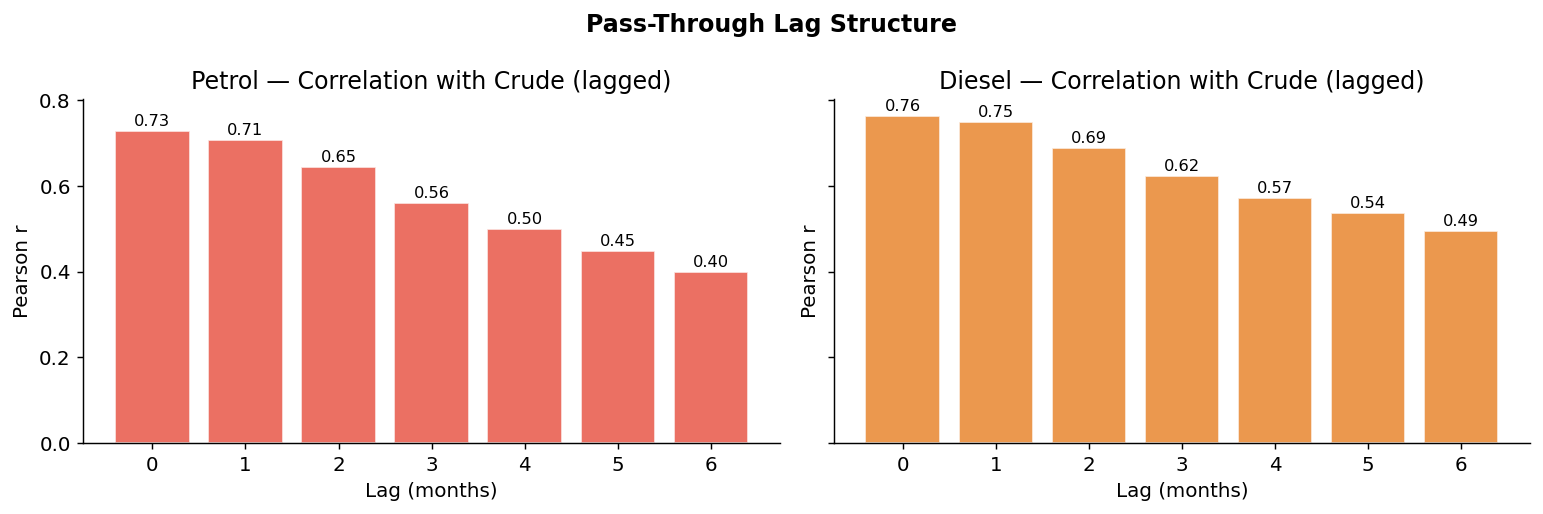

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
colors = {"Petrol": "#e74c3c", "Diesel": "#e67e22"}

for ax, fuel in zip(axes, ["Petrol", "Diesel"]):
    sub = lag_df[lag_df["Fuel"] == fuel]
    bars = ax.bar(sub["Lag (months)"], sub["Correlation"],
                  color=colors[fuel], alpha=0.8, edgecolor="white")
    for bar, val in zip(bars, sub["Correlation"]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f"{val:.2f}", ha="center", va="bottom", fontsize=9)
    ax.set_title(f"{fuel} — Correlation with Crude (lagged)")
    ax.set_xlabel("Lag (months)")
    ax.set_ylabel("Pearson r")
    ax.set_xticks(range(7))

plt.suptitle("Pass-Through Lag Structure", fontweight="bold")
plt.tight_layout()
plt.show()

In [ ]:
# Use brent_usd directly — avoids noisy INR conversion
df["d_crude"]  = df["brent_usd"].diff()
df["crude_up"] = df["d_crude"].clip(lower=0)
df["crude_dn"] = df["d_crude"].clip(upper=0).abs()

print("=== Asymmetric Pass-Through (Houck Decomposition) ===\n")
results = []

for fuel, col in [("Petrol", "petrol_inr_delhi"), ("Diesel", "diesel_inr_delhi")]:
    df["d_fuel"] = df[col].diff()
    model_df = df[["d_fuel", "crude_up", "crude_dn"]].dropna()

    X = add_constant(model_df[["crude_up", "crude_dn"]])
    res = OLS(model_df["d_fuel"], X).fit()

    b_up, b_dn = res.params["crude_up"], res.params["crude_dn"]
    p_up, p_dn = res.pvalues["crude_up"], res.pvalues["crude_dn"]
    wald_p = float(res.wald_test("crude_up = crude_dn").pvalue)

    print(f"  {fuel}")
    print(f"    β_up = {b_up:.4f}  (p={p_up:.3f})  ← crude rises → price rises")
    print(f"    β_dn = {b_dn:.4f}  (p={p_dn:.3f})  ← crude falls → price falls")
    print(f"    R²   = {res.rsquared:.3f}")
    print(f"    Wald test (β_up = β_dn): p = {wald_p:.3f}  →  "
          f"{'Asymmetric ✓' if wald_p < 0.10 else 'Symmetric'}\n")

    results.append({"fuel": fuel, "b_up": b_up, "b_dn": b_dn,
                    "ratio": b_up/b_dn if b_dn else np.nan,
                    "r2": res.rsquared, "wald_p": wald_p})

asym_df = pd.DataFrame(results)
asym_df

=== Asymmetric Pass-Through (Houck Decomposition) ===

  Petrol
    β_up = -0.0985  (p=0.517)  ← crude rises → price rises
    β_dn = -0.1579  (p=0.202)  ← crude falls → price falls
    R²   = 0.026
    Wald test (β_up = β_dn): p = 0.685  →  Symmetric

  Diesel
    β_up = 0.0716  (p=0.589)  ← crude rises → price rises
    β_dn = -0.1804  (p=0.096)  ← crude falls → price falls
    R²   = 0.073
    Wald test (β_up = β_dn): p = 0.052  →  Asymmetric ✓



,fuel,b_up,b_dn,ratio,r2,wald_p
0,Petrol,-0.098527,-0.157889,0.624027,0.025816,0.684698
1,Diesel,0.071584,-0.180442,-0.396715,0.073225,0.051616


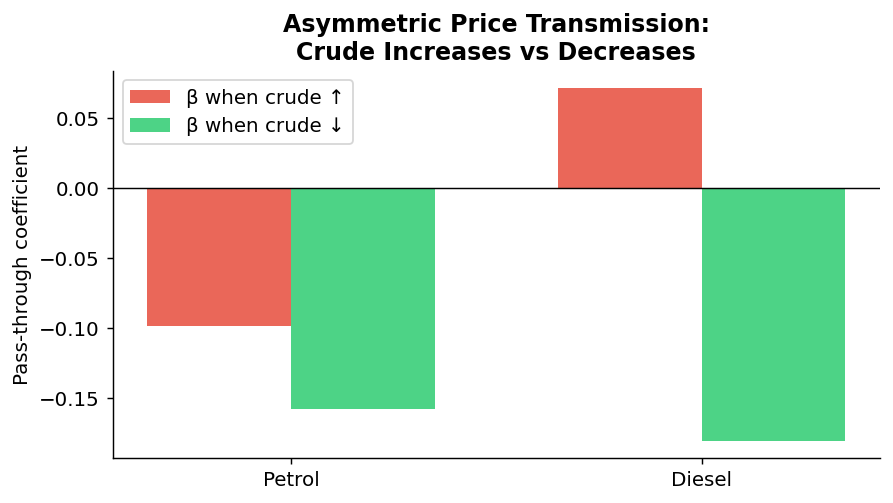

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(2)
w = 0.35

ax.bar(x - w/2, asym_df["b_up"], w, label="β when crude ↑", color="#e74c3c", alpha=0.85)
ax.bar(x + w/2, asym_df["b_dn"], w, label="β when crude ↓", color="#2ecc71", alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(["Petrol", "Diesel"])
ax.set_ylabel("Pass-through coefficient")
ax.set_title("Asymmetric Price Transmission:\nCrude Increases vs Decreases", fontweight="bold")
ax.legend()
ax.axhline(0, color="black", lw=0.8)
plt.tight_layout()
plt.show()

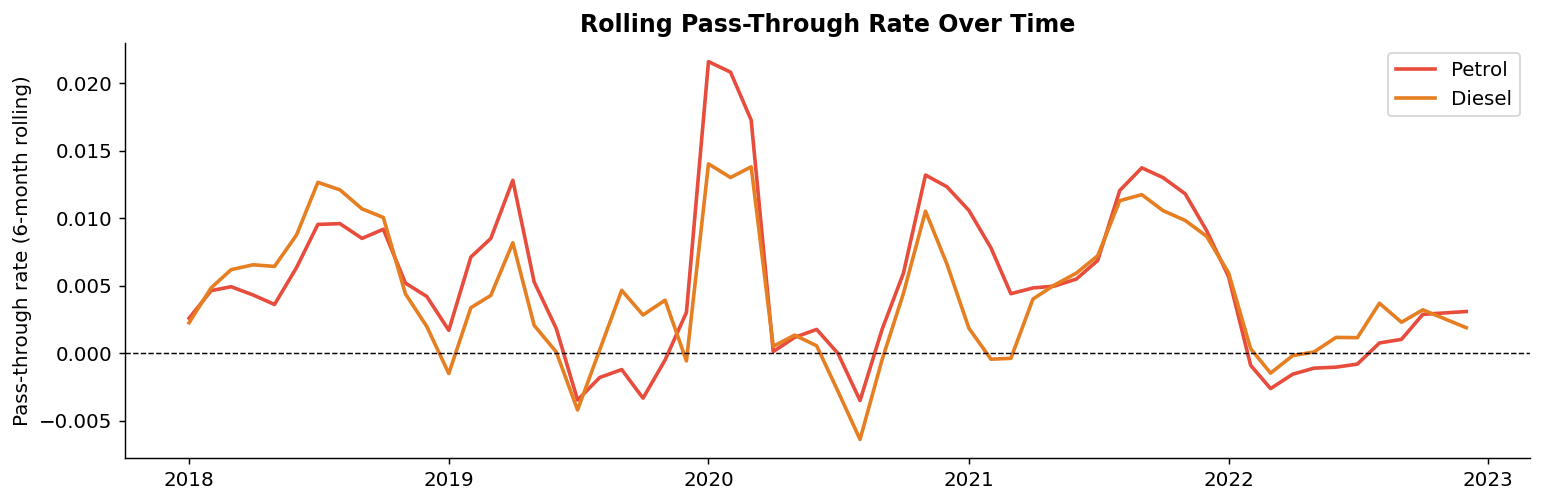

In [ ]:
df["pt_petrol"] = (df["petrol_inr_delhi"].diff(6) /
                   df["crude_inr_per_barrel"].diff(6)).rolling(3).mean()
df["pt_diesel"] = (df["diesel_inr_delhi"].diff(6) /
                   df["crude_inr_per_barrel"].diff(6)).rolling(3).mean()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df["date"], df["pt_petrol"], color="#e74c3c", lw=2, label="Petrol")
ax.plot(df["date"], df["pt_diesel"], color="#e67e22", lw=2, label="Diesel")
ax.axhline(0, color="black", lw=0.8, ls="--")
ax.set_ylabel("Pass-through rate (6-month rolling)")
ax.set_title("Rolling Pass-Through Rate Over Time", fontweight="bold")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
print("=" * 60)
print("KEY FINDINGS")
print("=" * 60)

for _, r in asym_df.iterrows():
    direction = "rises faster than it falls" if r["b_up"] > r["b_dn"] else "falls faster than it rises"
    asymmetric = "YES" if r["wald_p"] < 0.10 else "NO"
    print(f"""
{r['fuel']}:
  Crude ↑ pass-through : {r['b_up']:.4f} ₹/litre per ₹1/barrel crude rise
  Crude ↓ pass-through : {r['b_dn']:.4f} ₹/litre per ₹1/barrel crude fall
  Ratio (up/down)      : {r['ratio']:.2f}x
  Statistically asymmetric? {asymmetric} (Wald p={r['wald_p']:.3f})
  → {r['fuel']} price {direction}
""")

KEY FINDINGS

Petrol:
  Crude ↑ pass-through : -0.0985 ₹/litre per ₹1/barrel crude rise
  Crude ↓ pass-through : -0.1579 ₹/litre per ₹1/barrel crude fall
  Ratio (up/down)      : 0.62x
  Statistically asymmetric? NO (Wald p=0.685)
  → Petrol price rises faster than it falls


Diesel:
  Crude ↑ pass-through : 0.0716 ₹/litre per ₹1/barrel crude rise
  Crude ↓ pass-through : -0.1804 ₹/litre per ₹1/barrel crude fall
  Ratio (up/down)      : -0.40x
  Statistically asymmetric? YES (Wald p=0.052)
  → Diesel price rises faster than it falls

